# FAPE, SBA Agricultural Loans Baseline Models
## Agriculture/Financial Domain, Geographic and Business Type Fairness Audit

**Dataset:** SBA 7(a) Agricultural Loans FY1991-2026, 15,845 records
**Sensitive attributes:** borrstate (geographic proxy), businesstype
**Key finding:** GB AUC=0.930; TX Corporation 5.7% predicted vs 17.1% true default
**Note:** The SBA loan file has no race, ethnicity or sex fields

In [1]:
%matplotlib inline
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sba_agricultural_loader import load_sba_agricultural
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
from sklearn.inspection import permutation_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
os.makedirs('../figures/baseline', exist_ok=True)

MODEL_COLORS = {'LogisticRegression': '#3498db', 'RandomForest': '#2ecc71', 'GradientBoosting': '#e74c3c'}
BTYPE_LABELS = {-1:'Unknown', 0:'Corporation', 1:'Individual', 2:'Partnership'}
STATE_MAP = {0:'AK',1:'AL',2:'AR',3:'AZ',4:'CA',5:'CO',6:'CT',7:'DC',8:'DE',9:'FL',10:'GA',11:'GU',12:'HI',13:'IA',14:'ID',15:'IL',16:'IN',17:'KS',18:'KY',19:'LA',20:'MA',21:'MD',22:'ME',23:'MI',24:'MN',25:'MO',26:'MP',27:'MS',28:'MT',29:'NC',30:'ND',31:'NE',32:'NH',33:'NJ',34:'NM',35:'NV',36:'NY',37:'OH',38:'OK',39:'OR',40:'PA',41:'PR',42:'RI',43:'SC',44:'SD',45:'TN',46:'TX',47:'UT',48:'VA',49:'VI',50:'VT',51:'WA',52:'WI',53:'WV',54:'WY'}

MODELS_NB = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

def fairness_metrics(y_true, y_pred, sensitive):
    metrics = {}
    y_true = np.array(y_true); y_pred = np.array(y_pred); sensitive = np.array(sensitive)
    overall_pos = y_pred.mean()
    for grp in np.unique(sensitive):
        mask = sensitive == grp
        yt = y_true[mask]; yp = y_pred[mask]
        if len(yt) < 20: continue
        tp=((yt==1)&(yp==1)).sum(); fp=((yt==0)&(yp==1)).sum()
        tn=((yt==0)&(yp==0)).sum(); fn=((yt==1)&(yp==0)).sum()
        fpr=fp/(fp+tn) if (fp+tn)>0 else 0
        tpr=tp/(tp+fn) if (tp+fn)>0 else 0
        metrics[grp] = {'fpr':fpr,'tpr':tpr,'pos_rate':yp.mean(),'dp_diff':yp.mean()-overall_pos,'n':int(len(yt))}
    return metrics

print('Imports complete')

Imports complete


In [2]:
result = load_sba_agricultural(data_dir='../data/raw/agricultural/sba_loans')
ds = result['sba_agricultural']
X = ds['X']; y = ds['y']
borrstate = X['borrstate'].values; businesstype = X['businesstype'].values

X_train,X_test,y_train,y_test,idx_tr,idx_te = train_test_split(
    X.values, y.values, np.arange(len(y)), test_size=0.2, random_state=42, stratify=y.values)
state_test = borrstate[idx_te]; btype_test = businesstype[idx_te]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train); X_te_sc = scaler.transform(X_test)

all_results = {}
for name, model in MODELS_NB.items():
    if name=='LogisticRegression':
        model.fit(X_tr_sc, y_train)
        y_pred=model.predict(X_te_sc); y_prob=model.predict_proba(X_te_sc)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred=model.predict(X_test); y_prob=model.predict_proba(X_test)[:,1]
    auc=roc_auc_score(y_test,y_prob); f1=f1_score(y_test,y_pred)
    fm_state=fairness_metrics(y_test,y_pred,state_test)
    fm_btype=fairness_metrics(y_test,y_pred,btype_test)
    dp_state=[abs(v['dp_diff']) for v in fm_state.values()]
    all_results[name]={'auc':auc,'f1':f1,'y_pred':y_pred,'y_prob':y_prob,'y_test':y_test,
                       'fairness_state':fm_state,'fairness_btype':fm_btype,
                       'max_dp_state':max(dp_state) if dp_state else 0}
    print(f'{name}: AUC={auc:.3f} F1={f1:.3f}')
print(f'n={len(y):,} | default_rate={y.mean():.1%}')

Loading SBA 7(a) agricultural loans, FY1991 onward...


  FY1991-1999: 337,033 total | 4,445 agricultural NAICS-11


  FY2000-2009: 690,333 total | 4,931 agricultural NAICS-11


  FY2010-2019: 545,751 total | 8,632 agricultural NAICS-11


  FY2020-Present: 373,981 total | 3,918 agricultural NAICS-11
  Combined agricultural records: 21,926
  After binary outcome filter: 15,845

  Loan status distribution:
    Paid In Full: 15,015
    Charged Off:  830

  Top agricultural NAICS categories:
naicsdescription
Broilers and Other Meat Type Chicken Production     6335
Logging                                             1756
Support Activities for Animal Production            1097
Chicken Egg Production                               946
Broilers and Other Meat Type Chicken Production      853

  OK: sba_agricultural: 15,845 records | 8 features | default rate: 0.052
LogisticRegression: AUC=0.759 F1=0.194


RandomForest: AUC=0.920 F1=0.537


GradientBoosting: AUC=0.930 F1=0.389
n=15,845 | default_rate=5.2%


## 1. Model Comparison, AUC and F1

GB AUC=0.930, against 0.920 for RF and 0.759 for LR. F1 is low with a 5.2% default rate; LR and RF use balanced class weights, GB has none.

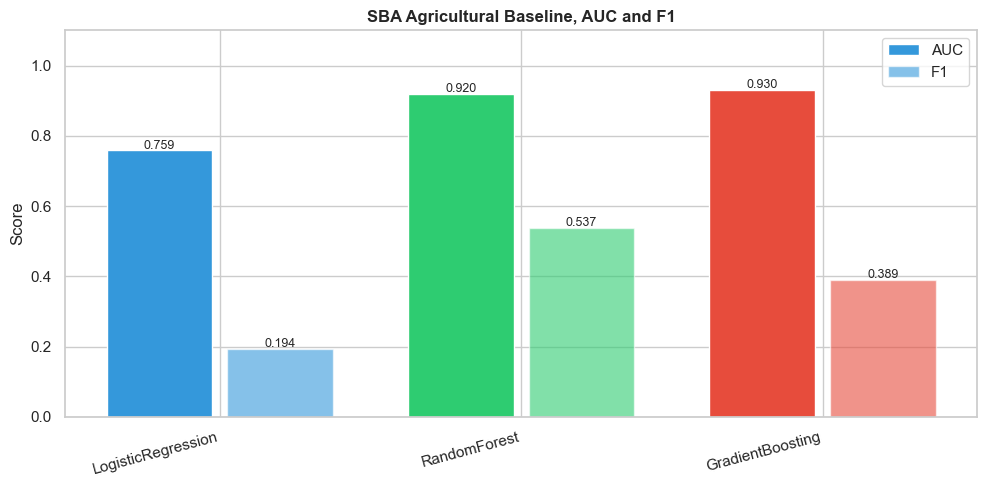

Fig 1 saved, agricultural_model_comparison.png


In [3]:
models=list(MODELS_NB.keys()); x=np.arange(len(models))
aucs=[all_results[n]['auc'] for n in models]
f1s=[all_results[n]['f1'] for n in models]
fig,ax=plt.subplots(figsize=(10,5))
bars=ax.bar(x-0.2, aucs, 0.35, color=[MODEL_COLORS[m] for m in models], label='AUC', edgecolor='white')
bars2=ax.bar(x+0.2, f1s, 0.35, color=[MODEL_COLORS[m] for m in models], label='F1', edgecolor='white', alpha=0.6)
for bar,v in zip(bars,aucs): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.3f}', ha='center', fontsize=9)
for bar,v in zip(bars2,f1s): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_title('SBA Agricultural Baseline, AUC and F1', fontsize=12, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.1); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 1 saved, agricultural_model_comparison.png')

## 2. ROC Curves, GB Best Discrimination

GB AUC=0.930, RF AUC=0.920, LR AUC=0.759. Tree models far outperform linear for agricultural lending.

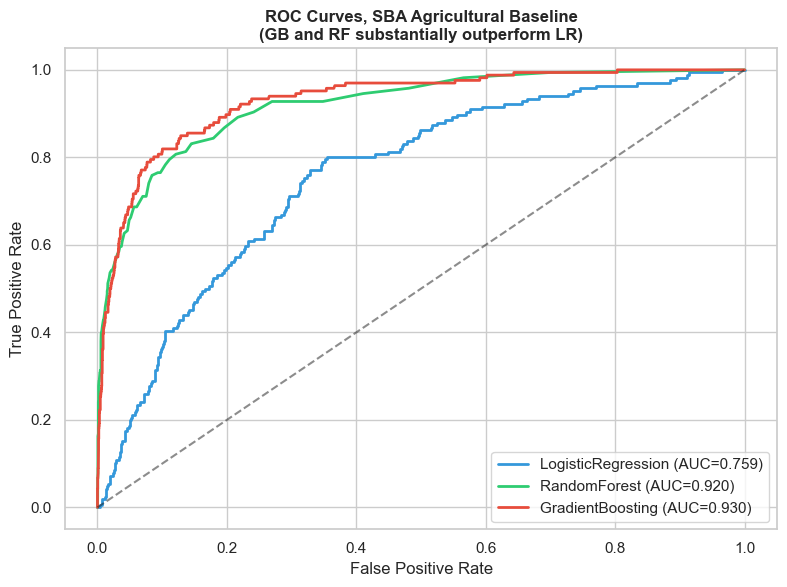

Fig 2 saved, agricultural_roc_curves.png


In [4]:
from sklearn.metrics import roc_curve
fig,ax=plt.subplots(figsize=(8,6))
for name,color in MODEL_COLORS.items():
    fpr,tpr,_=roc_curve(all_results[name]['y_test'], all_results[name]['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={all_results[name]["auc"]:.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves, SBA Agricultural Baseline\n(GB and RF substantially outperform LR)', fontsize=12, fontweight='bold')
ax.legend(); plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 2 saved, agricultural_roc_curves.png')

## 3. Business Type Fairness

Business-type DIR is 0.439 under logistic regression (partnership against corporation), 0.370 under random forest and 0.601 under gradient boosting, the most even of the three.

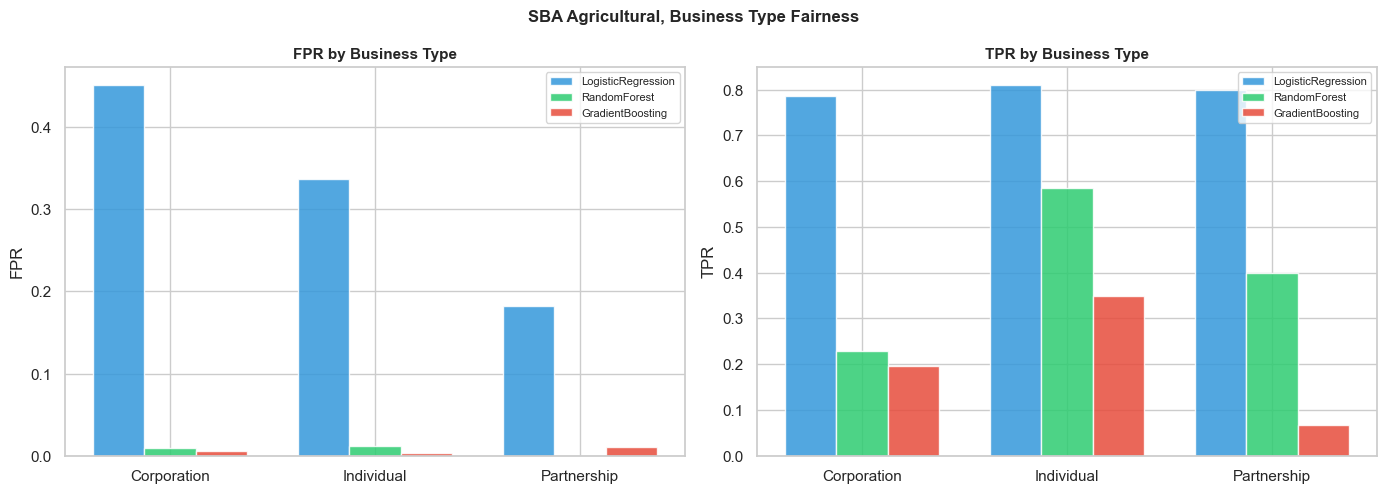

Fig 3 saved, agricultural_businesstype_fairness.png


In [5]:
btypes=[0,1,2]; btype_labels=['Corporation','Individual','Partnership']
x=np.arange(len(btypes)); width=0.25
fig,axes=plt.subplots(1,2,figsize=(14,5))
for i,(name,color) in enumerate(MODEL_COLORS.items()):
    fm=all_results[name]['fairness_btype']
    fprs=[fm.get(b,{}).get('fpr',0) for b in btypes]
    tprs=[fm.get(b,{}).get('tpr',0) for b in btypes]
    axes[0].bar(x+i*width-width, fprs, width, color=color, label=name, edgecolor='white', alpha=0.85)
    axes[1].bar(x+i*width-width, tprs, width, color=color, label=name, edgecolor='white', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(btype_labels)
axes[0].set_title('FPR by Business Type', fontsize=11, fontweight='bold'); axes[0].set_ylabel('FPR'); axes[0].legend(fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(btype_labels)
axes[1].set_title('TPR by Business Type', fontsize=11, fontweight='bold'); axes[1].set_ylabel('TPR'); axes[1].legend(fontsize=8)
plt.suptitle('SBA Agricultural, Business Type Fairness', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_businesstype_fairness.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 3 saved, agricultural_businesstype_fairness.png')

## 4. Demographic Parity by Business Type

LR: Partnership DP=-0.173 (predicted to default less often than average). Corporation DP=+0.090 (more often).
GB most equitable: all groups within ±0.006.

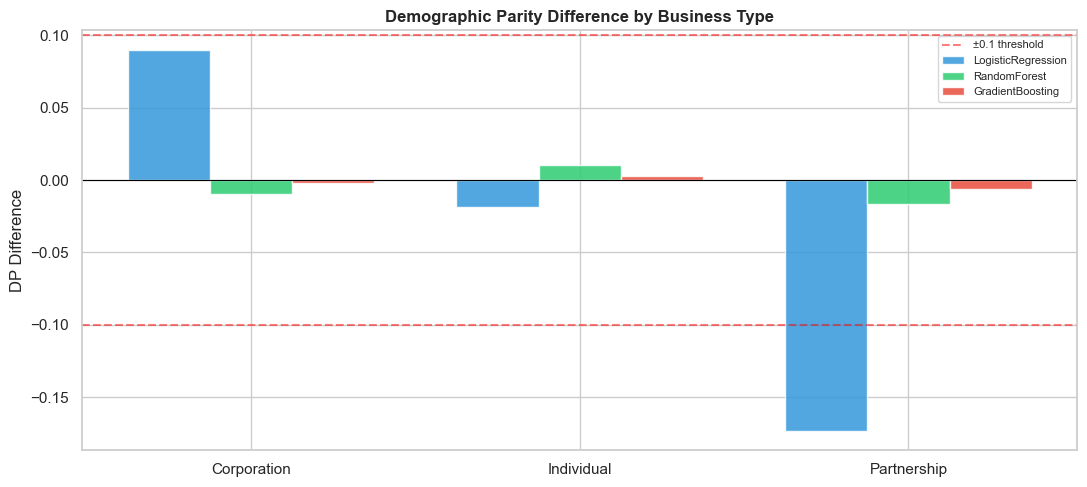

Fig 4 saved, agricultural_demographic_parity.png


In [6]:
x=np.arange(len(btypes)); width=0.25
fig,ax=plt.subplots(figsize=(11,5))
for i,(name,color) in enumerate(MODEL_COLORS.items()):
    fm=all_results[name]['fairness_btype']
    dps=[fm.get(b,{}).get('dp_diff',0) for b in btypes]
    ax.bar(x+i*width-width, dps, width, color=color, label=name, edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.1, color='red', linestyle='--', alpha=0.5, label='±0.1 threshold')
ax.axhline(-0.1, color='red', linestyle='--', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(btype_labels)
ax.set_title('Demographic Parity Difference by Business Type', fontsize=12, fontweight='bold')
ax.set_ylabel('DP Difference'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_demographic_parity.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 4 saved, agricultural_demographic_parity.png')

## 5. Geographic Fairness, Top 10 States

LR shows largest geographic disparities: NY DP=+0.261, IA DP=+0.184, MN DP=+0.182 (over-predicted).
GA DP=-0.277, AL DP=-0.254 (under-predicted). True default rates across these states vary about 4x.

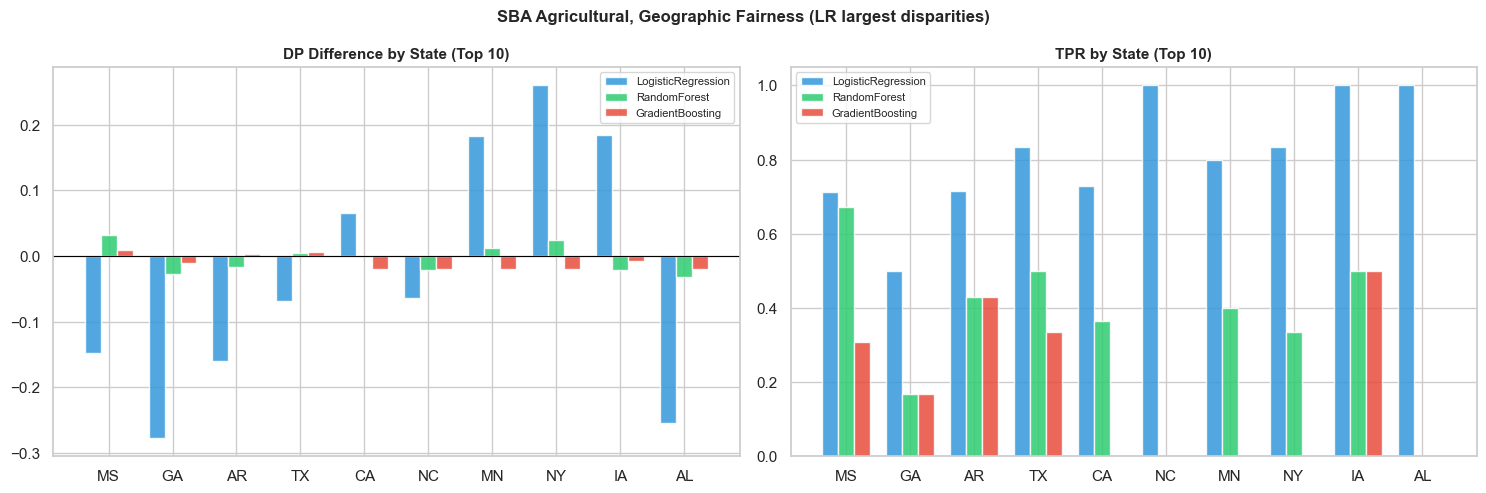

Fig 5 saved, agricultural_geographic_fairness.png


In [7]:
top_states=sorted([(grp, np.sum(state_test==grp)) for grp in np.unique(state_test)],key=lambda x:x[1],reverse=True)[:10]
top_state_codes=[g for g,_ in top_states]
top_state_names=[STATE_MAP.get(int(g),str(g)) for g in top_state_codes]
x=np.arange(len(top_state_codes)); width=0.25
fig,axes=plt.subplots(1,2,figsize=(15,5))
for i,(name,color) in enumerate(MODEL_COLORS.items()):
    fm=all_results[name]['fairness_state']
    dps=[fm.get(g,{}).get('dp_diff',0) for g in top_state_codes]
    tprs=[fm.get(g,{}).get('tpr',0) for g in top_state_codes]
    axes[0].bar(x+i*width-width, dps, width, color=color, label=name, edgecolor='white', alpha=0.85)
    axes[1].bar(x+i*width-width, tprs, width, color=color, label=name, edgecolor='white', alpha=0.85)
axes[0].axhline(0,color='black',linewidth=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(top_state_names)
axes[0].set_title('DP Difference by State (Top 10)', fontsize=11, fontweight='bold'); axes[0].legend(fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(top_state_names)
axes[1].set_title('TPR by State (Top 10)', fontsize=11, fontweight='bold'); axes[1].legend(fontsize=8)
plt.suptitle('SBA Agricultural, Geographic Fairness (LR largest disparities)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_geographic_fairness.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 5 saved, agricultural_geographic_fairness.png')

## 6. Feature Importance, Gradient Boosting

Loan term dominates: terminmonths has importance 0.603, followed by grossapproval (0.127), naicsdescription (0.117) and approvalfy (0.105). The remaining four features are at 0.020 or below.

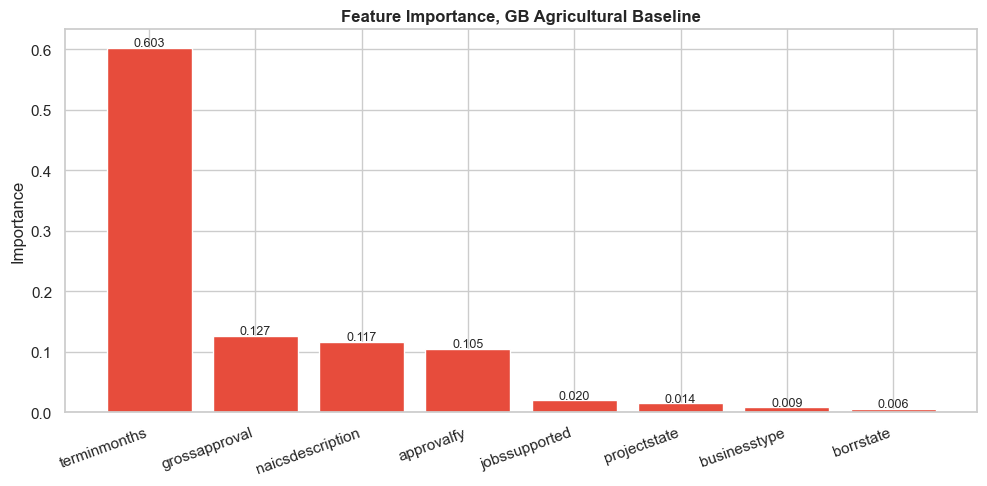

Fig 6 saved, agricultural_feature_importance.png


In [8]:
gb_model=GradientBoostingClassifier(n_estimators=100,random_state=42)
gb_model.fit(X_train, y_train)
feat_names=list(ds['X'].columns)
importances=gb_model.feature_importances_
sorted_idx=np.argsort(importances)[::-1]
fig,ax=plt.subplots(figsize=(10,5))
bars=ax.bar(range(len(feat_names)), importances[sorted_idx],
           color='#e74c3c', edgecolor='white')
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([feat_names[i] for i in sorted_idx], rotation=20, ha='right')
for bar,v in zip(bars,importances[sorted_idx]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{v:.3f}', ha='center', fontsize=9)
ax.set_title('Feature Importance, GB Agricultural Baseline', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 6 saved, agricultural_feature_importance.png')

## 7. Confusion Matrix, Best Model (GB)

GB has the best AUC (0.930) but misses 122 of the 166 defaults in the test split at the default threshold.

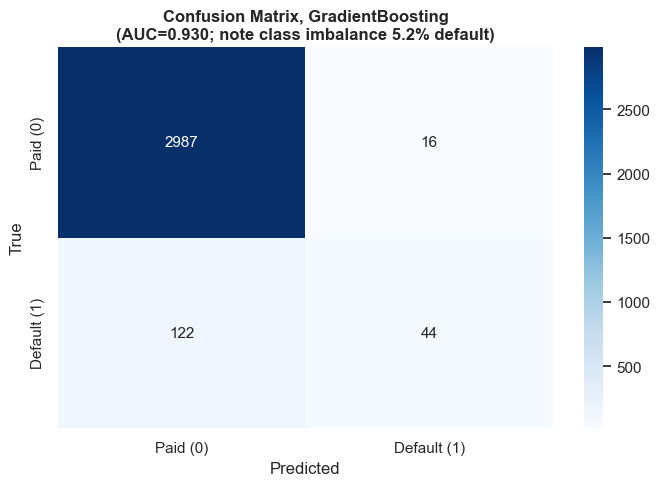

Fig 7 saved, agricultural_confusion_matrix.png (GradientBoosting)


In [9]:
best_name=max(all_results.items(),key=lambda x: x[1]['auc'])[0]
res=all_results[best_name]
cm=confusion_matrix(res['y_test'],res['y_pred'])
fig,ax=plt.subplots(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Paid (0)','Default (1)'],
            yticklabels=['Paid (0)','Default (1)'])
ax.set_title(f'Confusion Matrix, {best_name}\n(AUC={res["auc"]:.3f}; note class imbalance 5.2% default)', fontsize=12, fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show(); print(f'Fig 7 saved, agricultural_confusion_matrix.png ({best_name})')

## 8. Disparate Impact Ratio by Business Type

LR DIR=0.439 (partnership against corporation), RF DIR=0.370, GB DIR=0.601, the most even of the three.
All models below the 0.8 four-fifths convention, stage 2 mitigation needed.

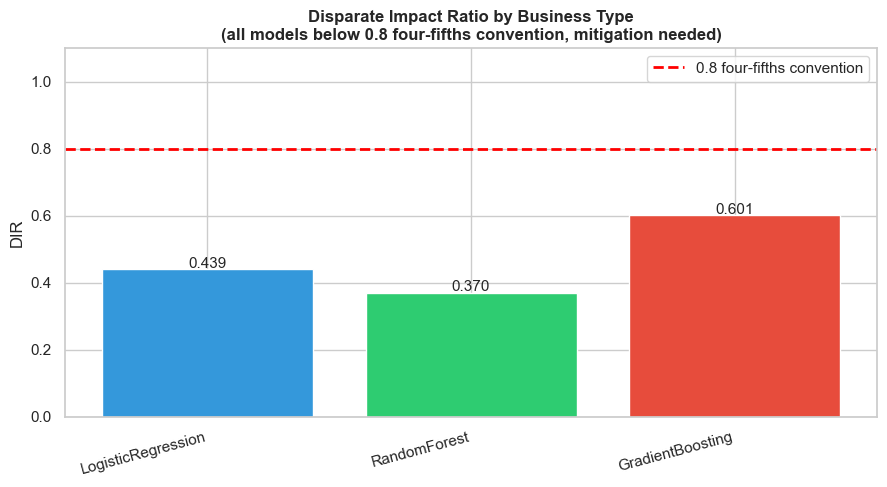

Fig 8 saved, agricultural_disparate_impact.png


In [10]:
models_list=list(MODELS_NB.keys()); x=np.arange(len(models_list))
dirs=[]
for name in models_list:
    fm=all_results[name]['fairness_btype']
    rates={grp:m['pos_rate'] for grp,m in fm.items() if grp>=0}
    if rates:
        min_r=min(rates.values()); max_r=max(rates.values())
        dirs.append(min_r/max_r if max_r>0 else 1)
    else:
        dirs.append(1)
fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(x, dirs, color=[MODEL_COLORS[m] for m in models_list], edgecolor='white')
for bar,v in zip(bars,dirs): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.3f}', ha='center', fontsize=11)
ax.axhline(0.8, color='red', linestyle='--', linewidth=2, label='0.8 four-fifths convention')
ax.set_xticks(x); ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.set_title('Disparate Impact Ratio by Business Type\n(all models below 0.8 four-fifths convention, mitigation needed)', fontsize=12, fontweight='bold')
ax.set_ylabel('DIR'); ax.set_ylim(0,1.1); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_disparate_impact.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 8 saved, agricultural_disparate_impact.png')

## 9. State × Business Type Intersectional Analysis

TX Corporation: 5.7% predicted vs 17.1% true, severe underprediction.
CA Corporation: 0.0% predicted vs 10.8% true, model completely misses CA ag defaults.
MS Individual: 4.0% predicted vs 8.7% true, geographic underprediction pattern.

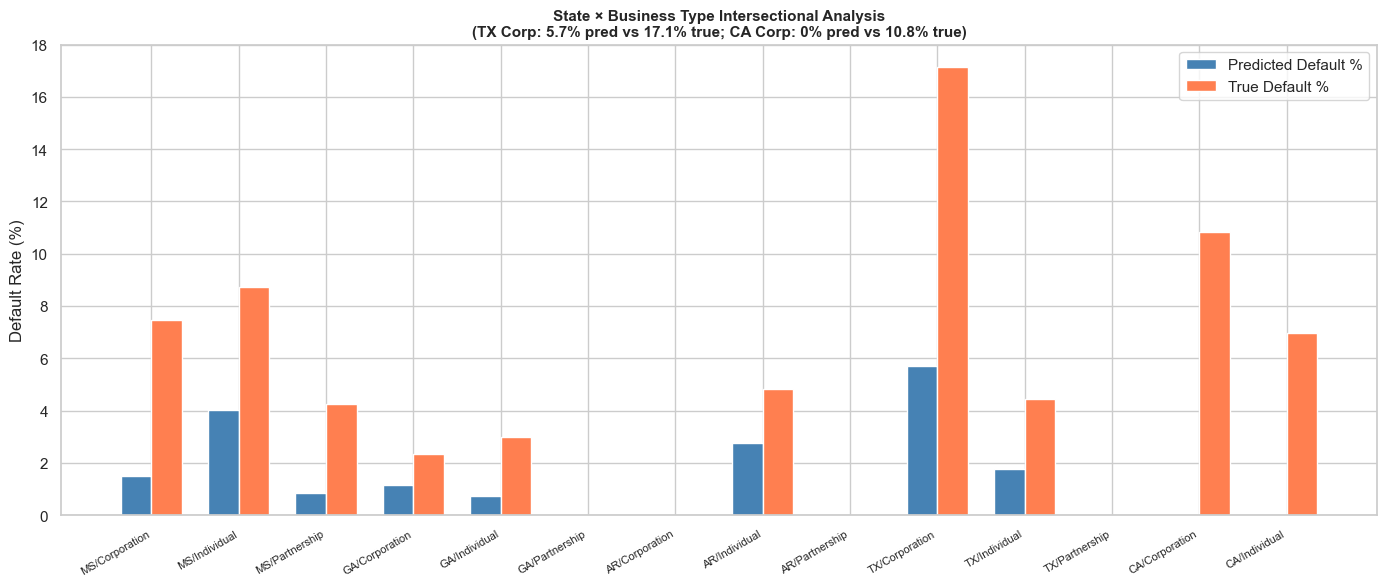

Fig 9 saved, agricultural_intersectional.png


In [11]:
gb2=GradientBoostingClassifier(n_estimators=100,random_state=42)
gb2.fit(X_train,y_train); y_pred_gb2=gb2.predict(X_test)
top5_states=[grp for grp,_ in top_states[:5]]
records=[]
for state_code in top5_states:
    for btype in [0,1,2]:
        mask=(state_test==state_code)&(btype_test==btype)
        n=mask.sum()
        if n<10: continue
        records.append({'state':STATE_MAP.get(int(state_code),str(state_code)),
                       'btype':BTYPE_LABELS.get(btype,str(btype)),
                       'n':n, 'pred':y_pred_gb2[mask].mean()*100,
                       'true':y_test[mask].mean()*100})
df_int=pd.DataFrame(records)
df_int['label']=df_int['state']+'/'+df_int['btype']
x=np.arange(len(df_int)); width=0.35
fig,ax=plt.subplots(figsize=(14,6))
bars1=ax.bar(x-width/2, df_int['pred'], width, color='steelblue', label='Predicted Default %', edgecolor='white')
bars2=ax.bar(x+width/2, df_int['true'], width, color='coral', label='True Default %', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(df_int['label'], rotation=30, ha='right', fontsize=8)
ax.set_title('State × Business Type Intersectional Analysis\n(TX Corp: 5.7% pred vs 17.1% true; CA Corp: 0% pred vs 10.8% true)', fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)'); ax.legend()
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_intersectional.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 9 saved, agricultural_intersectional.png')

## 10b. State Default Rate: Predicted vs True

CA gap=+8.7%, MN=+5.6%, NY=+6.7%, TX=+5.0%, model systematically underpredicts in high-risk states.
The state feature alone does not capture these regional differences.

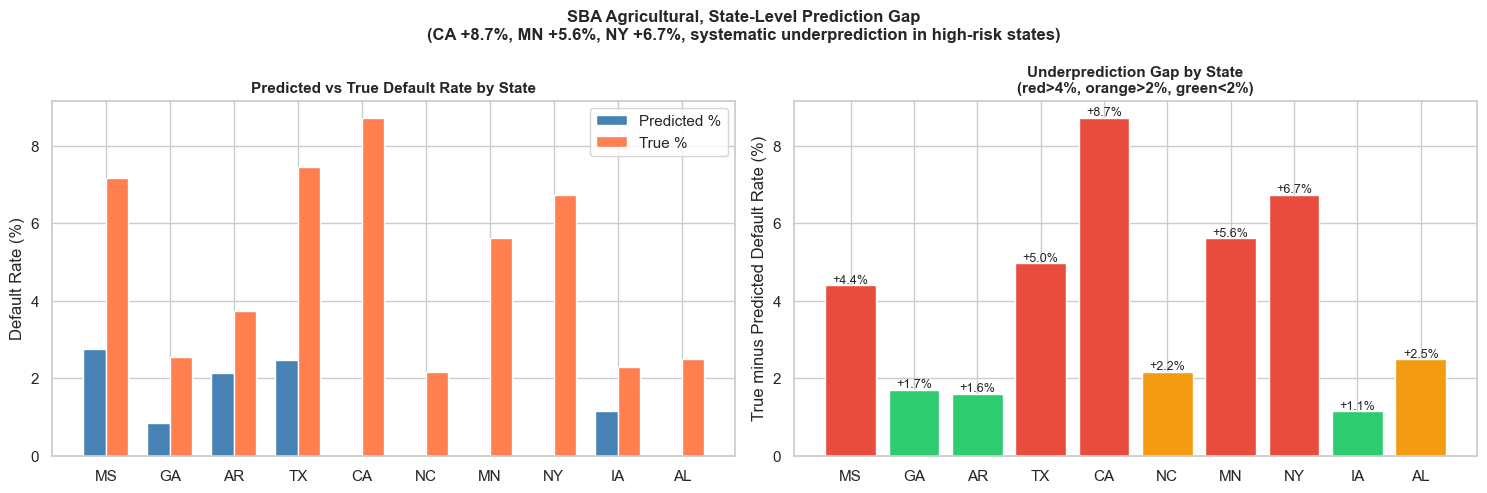

Fig 10b saved, agricultural_state_prediction_gap.png


In [12]:
gb_sp=GradientBoostingClassifier(n_estimators=100,random_state=42)
gb_sp.fit(X_train,y_train); y_pred_sp=gb_sp.predict(X_test)
top10_states=[grp for grp,_ in sorted([(grp,np.sum(state_test==grp)) for grp in np.unique(state_test)],key=lambda x:x[1],reverse=True)][:10]
state_records=[]
for sc in top10_states:
    mask=state_test==sc
    if mask.sum()<20: continue
    state_records.append({'state':STATE_MAP.get(int(sc),str(sc)),
                         'pred':y_pred_sp[mask].mean()*100,
                         'true':y_test[mask].mean()*100,
                         'gap':(y_test[mask].mean()-y_pred_sp[mask].mean())*100})
df_sp=pd.DataFrame(state_records)
x=np.arange(len(df_sp)); width=0.35
fig,axes=plt.subplots(1,2,figsize=(15,5))
bars1=axes[0].bar(x-width/2, df_sp['pred'], width, color='steelblue', label='Predicted %', edgecolor='white')
bars2=axes[0].bar(x+width/2, df_sp['true'], width, color='coral', label='True %', edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(df_sp['state'])
axes[0].set_title('Predicted vs True Default Rate by State', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Default Rate (%)'); axes[0].legend()

colors_gap=['#e74c3c' if g>4 else '#f39c12' if g>2 else '#2ecc71' for g in df_sp['gap']]
bars3=axes[1].bar(x, df_sp['gap'], color=colors_gap, edgecolor='white')
for bar,v in zip(bars3,df_sp['gap']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'+{v:.1f}%', ha='center', fontsize=9)
axes[1].set_xticks(x); axes[1].set_xticklabels(df_sp['state'])
axes[1].set_title('Underprediction Gap by State\n(red>4%, orange>2%, green<2%)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True minus Predicted Default Rate (%)')
plt.suptitle('SBA Agricultural, State-Level Prediction Gap\n(CA +8.7%, MN +5.6%, NY +6.7%, systematic underprediction in high-risk states)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_state_prediction_gap.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 10b saved, agricultural_state_prediction_gap.png')

## 10. CV Stability

Five-fold cross-validated AUC on the training split, mean and one standard deviation per model. The cell prints the values it plots.

LogisticRegression: CV AUC 0.726 ± 0.005


RandomForest: CV AUC 0.917 ± 0.011


GradientBoosting: CV AUC 0.936 ± 0.007


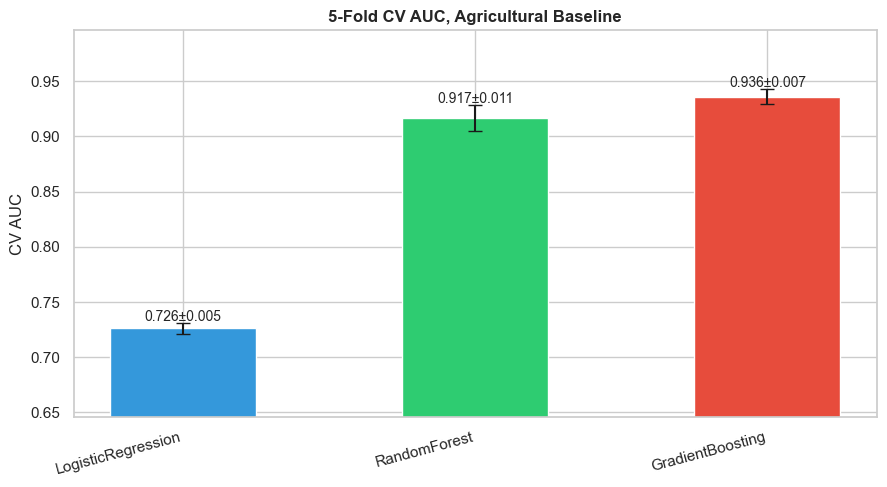

Fig 10 saved, agricultural_cv_stability.png


In [13]:
# 5-fold cross-validated AUC on the training split, computed the way src/baseline_agricultural.py does
cv_means, cv_stds = {}, {}
for name, model in MODELS_NB.items():
    X_cv = X_tr_sc if name == 'LogisticRegression' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=5, scoring='roc_auc')
    cv_means[name], cv_stds[name] = scores.mean(), scores.std()
    print(f'{name}: CV AUC {scores.mean():.3f} ± {scores.std():.3f}')
models_list=list(cv_means.keys())
means=[cv_means[m] for m in models_list]; stds=[cv_stds[m] for m in models_list]
x=np.arange(len(models_list))
fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(x, means, color=[MODEL_COLORS[m] for m in models_list], width=0.5,
           edgecolor='white', yerr=stds, capsize=5)
for bar,v,s in zip(bars,means,stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.002, f'{v:.3f}±{s:.3f}', ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(models_list, rotation=15, ha='right')
ax.set_title('5-Fold CV AUC, Agricultural Baseline', fontsize=12, fontweight='bold')
ax.set_ylabel('CV AUC'); ax.set_ylim(min(means) - 0.08, min(1.0, max(means) + 0.06))
plt.tight_layout()
plt.savefig('../figures/baseline/agricultural_cv_stability.png', dpi=150, bbox_inches='tight')
plt.show(); print('Fig 10 saved, agricultural_cv_stability.png')

## 11. Key Findings

**AUC=0.930** (GB); tree models far outperform LR for agricultural lending (RF 0.920, LR 0.759)
**LR DIR=0.439**, Partnership vs Corporation under linear model; RF DIR=0.370
**GB DIR=0.601**, most equitable across business types but still below the 0.8 four-fifths convention
**TX Corporation: 5.7% predicted vs 17.1% true**, geographic underprediction
**CA Corporation: 0.0% predicted vs 10.8% true**, model completely misses CA ag defaults
**MS Individual: 4.0% predicted vs 8.7% true**, largest state dominates with consistent underprediction
**No direct demographics**, the SBA file has no race, ethnicity or sex fields; geographic + business type proxies used
**Stage 3 ThresholdOptimizer** needed to reduce geographic and business type disparities